# Q3: Which Patients Fall Above the Top 10% in Charges, and What Do They Have in Common?

In [ ]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import math

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Projects/Healthcare-Insurance-Analysis/data/processed/insurance_clean.csv')
df.head()

,Unnamed: 0,age,sex,bmi,children,smoker,region,charges
0,0,19,female,27.900,0,yes,southwest,16884.92400
1,1,18,male,33.770,1,no,southeast,1725.55230
2,2,28,male,33.000,3,no,southeast,4449.46200
3,3,33,male,22.705,0,no,northwest,21984.47061
4,4,32,male,28.880,0,no,northwest,3866.85520


## 1. Select the Top 10% by Charges

This mirrors the SQL Server query (`TOP 10 PERCENT ... ORDER BY charges DESC`), which selects the top 10% of *rows* rather than a fixed percentile cutoff. We reproduce the same row count in pandas so the two match exactly.

In [ ]:
n = len(df)
top_n = math.ceil(n * 0.10)  # SQL Server's TOP N PERCENT rounds up

top10 = df.sort_values('charges', ascending=False).head(top_n)

print(f"Total patients: {n}")
print(f"Top 10% count: {top_n}")
print(f"Minimum charge in this group: ${top10['charges'].min():,.2f}")

Total patients: 1337
Top 10% count: 134
Minimum charge in this group: $34,838.87


**Finding:** The top 10% consists of 134 patients out of 1,337, all with charges of $34,838.87 or higher.

## 2. Common Characteristics (Grouped by Smoker Status)

This matches the second part of the SQL query — grouping the top 10% by smoking status and averaging age, BMI, and number of children.

In [ ]:
common = top10.groupby('smoker').agg(
    avg_age=('age', 'mean'),
    avg_bmi=('bmi', 'mean'),
    avg_children=('children', 'mean'),
    patients=('smoker', 'count')
).round(2)

print(common)

        avg_age  avg_bmi  avg_children  patients
smoker                                          
no        58.33    31.64          2.33         3
yes       41.40    35.74          1.20       131


**Finding:** Of the 134 patients in the top 10%, 131 (97.8%) are smokers and only 3 (2.2%) are non-smokers. Smoker patients in this group also have a notably higher average BMI (35.74 vs. 31.64) and are younger on average (41.40 vs. 58.33) — meaning the few non-smokers who reach this cost tier tend to be older, while smokers reach it regardless of age.

## 3. Additional Context: How Unusual Is This Smoker Rate?

In [ ]:
smoker_rate_top10 = (top10['smoker'] == 'yes').mean()
smoker_rate_overall = (df['smoker'] == 'yes').mean()

print(f"Smoker rate in top 10%: {smoker_rate_top10*100:.1f}%")
print(f"Smoker rate overall: {smoker_rate_overall*100:.1f}%")

Smoker rate in top 10%: 97.8%
Smoker rate overall: 20.5%


**Finding:** Smokers make up only 20.5% of the overall patient population, but 97.8% of the top 10% highest-charge group. This is by far the strongest common trait among the highest-cost patients.

In [ ]:
print("Region distribution in top 10% (%):")
print((top10['region'].value_counts(normalize=True) * 100).round(1))
print()
print("Sex distribution in top 10% (%):")
print((top10['sex'].value_counts(normalize=True) * 100).round(1))

Region distribution in top 10% (%):
region
southeast    41.0
southwest    23.9
northeast    20.1
northwest    14.9
Name: proportion, dtype: float64

Sex distribution in top 10% (%):
sex
male      62.7
female    37.3
Name: proportion, dtype: float64


**Finding:** Southeast is over-represented in the top 10% (41.0% of this group), consistent with Q1's finding that Southeast has both the highest average charges and the highest smoker rate. Males are also somewhat over-represented (62.7%).

## 4. Visualization

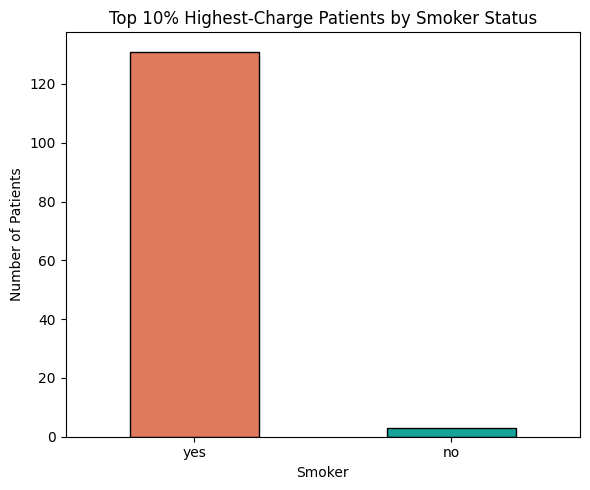

In [ ]:
plt.figure(figsize=(6, 5))
top10['smoker'].value_counts().reindex(['yes', 'no']).plot(
    kind='bar', color=['#e07a5f', '#17a398'], edgecolor='black')
plt.title('Top 10% Highest-Charge Patients by Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

## Summary

| Metric | Top 10% | Overall |
|---|---|---|
| Smoker rate | 97.8% | 20.5% |
| Avg BMI (smokers in group) | 35.74 | — |
| Avg age (smokers in group) | 41.40 | — |
| Top region | Southeast (41.0%) | — |

**Conclusion:** The patients in the top 10% of charges are overwhelmingly smokers (97.8%), with higher-than-average BMI. Southeast patients are over-represented in this group, consistent with the region's higher smoker rate found in Q1. This confirms that smoking — not age, region, or family size alone — is the dominant characteristic shared by the highest-cost patients.